In [1]:
#importing the required libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns



In [2]:
#importing data into jupyter notebook
df=pd.read_csv("C:/Users/sanja/OneDrive/Desktop/powerbi project/global_supply_chain_disruption_v1.csv")

In [3]:
# first five rows of the dataframe
df.head()

,Order_ID,Order_Date,Origin_City,Destination_City,Route_Type,Transportation_Mode,Product_Category,Base_Lead_Time_Days,Scheduled_Lead_Time_Days,Actual_Lead_Time_Days,Delay_Days,Delivery_Status,Disruption_Event,Geopolitical_Risk_Index,Weather_Severity_Index,Inflation_Rate_Pct,Shipping_Cost_USD,Order_Weight_Kg,Mitigation_Action_Taken
0,ORD-00BCB25B,2024-04-05,"Shanghai, CN","Los Angeles, US",Pacific,Sea,Textiles,18,21,18,0,On Time,NaN,0.81,8.9,1.83,1611.81,1781,Standard Shipping
1,ORD-EBDBACB7,2024-09-08,"Tokyo, JP","Singapore, SG",Intra-Asia,Air,Pharmaceuticals,2,5,2,0,On Time,NaN,0.70,5.9,2.44,76127.70,8142,Standard Shipping
2,ORD-4052DA06,2025-01-28,"Shenzhen, CN","Rotterdam, NL",Suez,Air,Semiconductors,3,4,4,0,On Time,NaN,0.46,8.1,3.86,13699.18,1706,Standard Shipping
3,ORD-03F41ABB,2025-02-04,"Santos, BR","Shanghai, CN",Commodity,Sea,Consumer Electronics,35,36,35,0,On Time,NaN,0.88,9.3,1.58,5448.24,5796,Standard Shipping
4,ORD-347A88A6,2025-05-20,"Hamburg, DE","New York, US",Atlantic,Sea,Raw Materials,12,13,12,0,On Time,NaN,0.55,2.9,3.12,1215.98,1569,Standard Shipping


In [4]:
df.shape

(10000, 19)

In [5]:
#checking the datatypes of the columns
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 19 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Order_ID                  10000 non-null  str    
 1   Order_Date                10000 non-null  str    
 2   Origin_City               10000 non-null  str    
 3   Destination_City          10000 non-null  str    
 4   Route_Type                10000 non-null  str    
 5   Transportation_Mode       10000 non-null  str    
 6   Product_Category          10000 non-null  str    
 7   Base_Lead_Time_Days       10000 non-null  int64  
 8   Scheduled_Lead_Time_Days  10000 non-null  int64  
 9   Actual_Lead_Time_Days     10000 non-null  int64  
 10  Delay_Days                10000 non-null  int64  
 11  Delivery_Status           10000 non-null  str    
 12  Disruption_Event          1267 non-null   str    
 13  Geopolitical_Risk_Index   10000 non-null  float64
 14  Weather_Severity_I

In [6]:
#changed the data type of order_date from string to datetime64
df["Order_Date"]=pd.to_datetime(df["Order_Date"])

In [7]:
df.dtypes

Order_ID                               str
Order_Date                  datetime64[us]
Origin_City                            str
Destination_City                       str
Route_Type                             str
Transportation_Mode                    str
Product_Category                       str
Base_Lead_Time_Days                  int64
Scheduled_Lead_Time_Days             int64
Actual_Lead_Time_Days                int64
Delay_Days                           int64
Delivery_Status                        str
Disruption_Event                       str
Geopolitical_Risk_Index            float64
Weather_Severity_Index             float64
Inflation_Rate_Pct                 float64
Shipping_Cost_USD                  float64
Order_Weight_Kg                      int64
Mitigation_Action_Taken                str
dtype: object

In [8]:
#checking for duplicate values and found no duplicate rows in the dataframe
df.duplicated().sum()

np.int64(0)

In [9]:
#checking for null values
df.isnull().sum()

Order_ID                       0
Order_Date                     0
Origin_City                    0
Destination_City               0
Route_Type                     0
Transportation_Mode            0
Product_Category               0
Base_Lead_Time_Days            0
Scheduled_Lead_Time_Days       0
Actual_Lead_Time_Days          0
Delay_Days                     0
Delivery_Status                0
Disruption_Event            8733
Geopolitical_Risk_Index        0
Weather_Severity_Index         0
Inflation_Rate_Pct             0
Shipping_Cost_USD              0
Order_Weight_Kg                0
Mitigation_Action_Taken        0
dtype: int64

In [10]:
df["Disruption_Event"].value_counts()

Disruption_Event
Port Congestion                            573
Geopolitical Conflict (Route Diversion)    521
Severe Weather (Typhoon/Storm)             173
Name: count, dtype: int64

In [11]:
# using groupby attribute we found geopolitical events are major for disruption in the supply chain, possible causes could be war and sanctions

df.groupby('Disruption_Event')['Delay_Days'].mean()

Disruption_Event
Geopolitical Conflict (Route Diversion)    12.930902
Port Congestion                             2.986038
Severe Weather (Typhoon/Storm)              5.508671
Name: Delay_Days, dtype: float64

In [12]:
#filling null values i.e none to no disruption
df["Disruption_Event"]=df["Disruption_Event"].fillna("No Disruption")

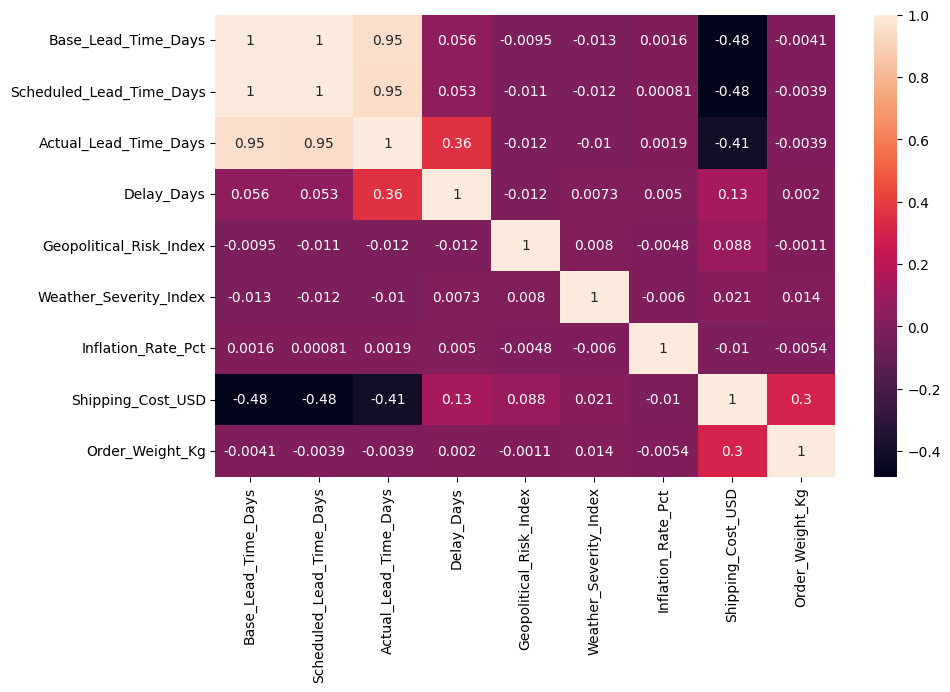

In [13]:
#using heatmap to find correlation beween different columns in the dataset

plt.figure(figsize=(10,6))
sns.heatmap(df.corr(numeric_only=True), annot=True)
plt.show()

In [14]:
##creating x for input and y for ouput

x= df[['Transportation_Mode','Shipping_Cost_USD','Order_Weight_Kg']]
y = df['Delivery_Status']

In [15]:
#imported the train test split
from sklearn.model_selection import train_test_split

In [16]:
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=.20,random_state=42)

In [17]:
#encoding the nominal category column to numerical col with onehotencoder
from sklearn.preprocessing import OneHotEncoder
ohe=OneHotEncoder(drop='first',sparse_output=False)
x_train_new=ohe.fit_transform(x_train[['Transportation_Mode']])
x_test_new=ohe.transform(x_test[['Transportation_Mode']])
x_test_new

array([[1.],
       [1.],
       [1.],
       ...,
       [1.],
       [1.],
       [1.]], shape=(2000, 1))

In [18]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
x_train = scaler.fit_transform(x_train[['Shipping_Cost_USD','Order_Weight_Kg']])
x_test = scaler.transform(x_test[['Shipping_Cost_USD','Order_Weight_Kg']])

In [19]:
from sklearn.preprocessing import LabelEncoder
le=LabelEncoder()
y_train_encoded=le.fit_transform(y_train)
y_test_encoded=le.transform(y_test)


In [22]:
#stacking horizonatly the encoded col with other cols from x
x_train_final=np.hstack((x_train,x_train_new))
x_test_final = np.hstack((x_test,x_test_new))

In [31]:
#appling linear regression model
from sklearn.linear_model import LogisticRegression
model = LogisticRegression()
model.fit(x_train_final, y_train_encoded)
y_pred = model.predict(x_test_final)

In [34]:
#checking the model accuracy
from sklearn.metrics import accuracy_score, classification_report
print("Accuracy:", accuracy_score(y_test_encoded, y_pred))


Accuracy: 0.882


In [33]:
#applying changes to the csv file
df.to_csv('cleaned_data.csv', index=False)